In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
udf=pd.read_csv('C://Users/harik/python pratice/Universities.csv', index_col='Univ')
udf

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,1310,89,22,13,22704,94
CalTech,1415,100,25,6,63575,81
CMU,1260,62,59,9,25026,72
Columbia,1310,76,24,12,31510,88
Cornell,1280,83,33,13,21864,90
Dartmouth,1340,89,23,10,32162,95
Duke,1315,90,30,12,31585,95
Georgetown,1255,74,24,12,20126,92
Harvard,1400,91,14,11,39525,97


#### Standardise the data

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(udf)
scaled_data

array([[ 0.41028362,  0.6575195 , -0.88986682,  0.07026045, -0.33141256,
         0.82030265],
       [ 1.39925928,  1.23521235, -0.73465749, -1.68625071,  2.56038138,
        -0.64452351],
       [-0.06065717, -0.76045386,  1.02438157, -0.93346022, -0.16712136,
        -1.65863393],
       [ 0.41028362, -0.02520842, -0.78639393, -0.18066972,  0.29164871,
         0.14422904],
       [ 0.12771914,  0.34241431, -0.32076595,  0.07026045, -0.39084607,
         0.36958691],
       [ 0.69284809,  0.6575195 , -0.83813038, -0.68253005,  0.33778044,
         0.93298158],
       [ 0.4573777 ,  0.71003703, -0.47597528, -0.18066972,  0.29695528,
         0.93298158],
       [-0.10775125, -0.13024348, -0.78639393, -0.18066972, -0.51381683,
         0.59494478],
       [ 1.25797704,  0.76255456, -1.30375836, -0.43159988,  0.85874344,
         1.15833946],
       [ 0.36318954, -0.07772595,  0.24833493, -1.43532055,  2.21481798,
         0.0315501 ],
       [ 1.06960072,  0.92010716, -0.47597528, -0.

### Build the Model

In [6]:
from sklearn.cluster import KMeans

In [7]:
model = KMeans(n_clusters=3)
model.fit(scaled_data)

KMeans(n_clusters=3)

In [8]:
model.labels_

array([1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 1, 2, 1,
       1, 2, 1])

In [9]:
udf['labels']= model.labels_

In [10]:
udf

,SAT,Top10,Accept,SFRatio,Expenses,GradRate,labels
Univ,,,,,,,
Brown,1310,89,22,13,22704,94,1
CalTech,1415,100,25,6,63575,81,1
CMU,1260,62,59,9,25026,72,2
Columbia,1310,76,24,12,31510,88,1
Cornell,1280,83,33,13,21864,90,1
Dartmouth,1340,89,23,10,32162,95,1
Duke,1315,90,30,12,31585,95,1
Georgetown,1255,74,24,12,20126,92,1
Harvard,1400,91,14,11,39525,97,1


In [11]:
model.inertia_

57.682628177489505

### Hyperparameter Tuning

In [12]:
wcss=[]

for i in range(1, 13):
    hmodel=KMeans(n_clusters=i)
    hmodel.fit(scaled_data)
    wcss.append(hmodel.inertia_)

wcss    

[149.99999999999997,
 64.47316262551323,
 46.984975659764274,
 40.369299749278255,
 28.531743735385618,
 29.25703261652043,
 18.87250712129735,
 16.553724258461894,
 13.305000114341167,
 11.792078038982089,
 9.933971656086499,
 7.415609155574281]

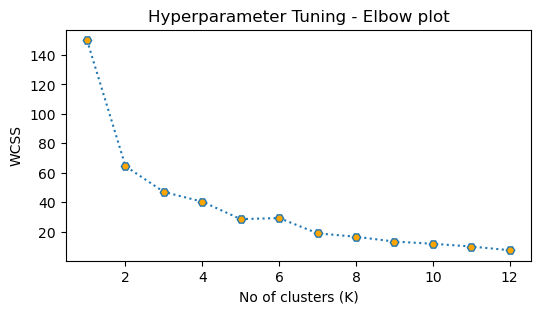

In [13]:
plt.figure(figsize=(6,3))
plt.plot(range(1,13), wcss,
        marker='H', markerfacecolor='orange',
        linestyle='dotted'
        )

plt.title('Hyperparameter Tuning - Elbow plot')
plt.xlabel('No of clusters (K)')
plt.ylabel('WCSS')
plt.show()

### Build final Model

In [14]:
final_model=KMeans(n_clusters=3)
final_model.fit(scaled_data)
final_model.labels_

array([0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 2, 1, 0, 1, 0, 1, 2, 2, 1, 2,
       2, 1, 0])

In [15]:
udf['labels']=model.labels_

In [16]:
udf

,SAT,Top10,Accept,SFRatio,Expenses,GradRate,labels
Univ,,,,,,,
Brown,1310,89,22,13,22704,94,1
CalTech,1415,100,25,6,63575,81,1
CMU,1260,62,59,9,25026,72,2
Columbia,1310,76,24,12,31510,88,1
Cornell,1280,83,33,13,21864,90,1
Dartmouth,1340,89,23,10,32162,95,1
Duke,1315,90,30,12,31585,95,1
Georgetown,1255,74,24,12,20126,92,1
Harvard,1400,91,14,11,39525,97,1


In [17]:
grp=udf.groupby('labels')

for x,y in grp:
    print(y)
    print('_'*50)

             SAT  Top10  Accept  SFRatio  Expenses  GradRate  labels
Univ                                                                
UCBerkeley  1240     95      40       17     15140        78       0
__________________________________________________
               SAT  Top10  Accept  SFRatio  Expenses  GradRate  labels
Univ                                                                  
Brown         1310     89      22       13     22704        94       1
CalTech       1415    100      25        6     63575        81       1
Columbia      1310     76      24       12     31510        88       1
Cornell       1280     83      33       13     21864        90       1
Dartmouth     1340     89      23       10     32162        95       1
Duke          1315     90      30       12     31585        95       1
Georgetown    1255     74      24       12     20126        92       1
Harvard       1400     91      14       11     39525        97       1
JohnsHopkins  1305     75      4

In [18]:
grp.agg('mean')

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
labels,,,,,,
0,1240.000000,95.000000,40.000000,17.000000,15140.000000,78.000000
1,1318.611111,85.277778,29.611111,11.055556,32736.222222,91.444444
2,1114.333333,47.000000,67.833333,17.000000,13384.666667,74.000000


#### Evaluate the model

In [19]:
from sklearn.metrics import silhouette_score

In [20]:
silhouette_score(scaled_data,udf['labels'])

0.2912179600668427